Abstract:
The current study aims to formulate a predictive model that can be used to calculate the likelihood of significant wildfires, which are characterized by their impact, i.e., larger than 300 acres, in the United States. A wide range of historical data from 1992 to 2015 has been used to formulate the proposed predictive model. A state-level monthly spatiotemporal data aggregation approach has been used to compare the performance of the baseline model, which is based on the Logistic Regression algorithm, with that of the advanced XGBoost algorithm. In addition, To maintain methodological integrity and eliminate the risk of data leakage, the validation of the proposed models has been carried out using the Time Series Split validation technique. The results of the proposed approach have confirmed that while geographic and seasonal factors act as strong linear predictors, the proposed XGBoost algorithm has been able to enhance the performance of the proposed predictive model by achieving higher Mean AUC (0.7873) compared to the baseline (0.7566).

In [12]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [14]:
df = pd.read_csv('wildfires_sample_100k.csv', low_memory=False)

df['MONTH'] = (df['DISCOVERY_DOY'] // 31) + 1
df.loc[df['MONTH'] > 12, 'MONTH'] = 12
df['is_notable'] = (df['FIRE_SIZE'] >= 300).astype(int)

st_units = df.groupby(['STATE', 'FIRE_YEAR', 'MONTH'])['is_notable'].max().reset_index()
st_units.rename(columns={'is_notable': 'target'}, inplace=True)
st_units = st_units.sort_values(['FIRE_YEAR', 'MONTH']).reset_index(drop=True)

summary_df = pd.DataFrame({
    "Metric": ["Total Observations", "Notable Fires (Target=1)", "Spatial Grain", "Temporal Grain"],
    "Value": [len(st_units), st_units['target'].sum(), "State", "Monthly"]
})
print("Table 1: Dataset Summary")
display(summary_df)

Table 1: Dataset Summary


,Metric,Value
0,Total Observations,8730
1,Notable Fires (Target=1),898
2,Spatial Grain,State
3,Temporal Grain,Monthly


Definition of Cutoff:
We define "Notable Fires" as those with a FIRE_SIZE of at least 300 acres. This cutoff is intentionally set to highlight events with large impacts that usually skirt around initial fire suppression efforts and require extensive multi-agency coordination.

Spatiotemporal Units:
The observational units are defined as State-Month. This level of detail enables easy alignment with administrative decision-making units (states) and the peak fire seasons driven by monthly climate patterns.

Aggregation Logic:
The individual fire observations are aggregated into these space-time units. The target variable is binary: 1 if at least one notable fire occurred in that particular state during that month/year, and 0 otherwise.

Dataset Summary:
The table above summarizes the extent and scale of the predictive grid that has been processed.

C:\Users\Davidcxzy\AppData\Local\Temp\ipykernel_20880\352267813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=st_units, x='MONTH', y='target', palette='viridis')


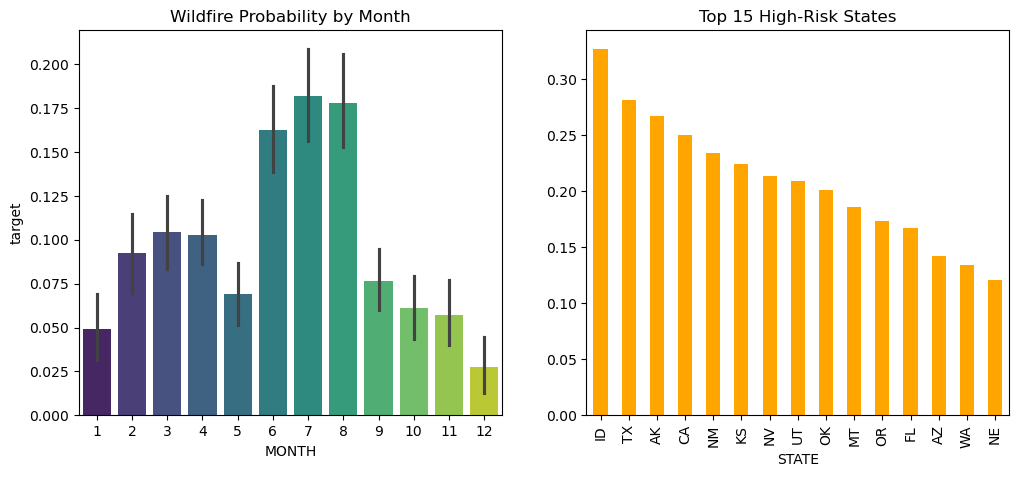

In [15]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=st_units, x='MONTH', y='target', palette='viridis')
plt.title('Wildfire Probability by Month')

plt.subplot(1, 2, 2)
st_units.groupby('STATE')['target'].mean().sort_values(ascending=False).head(15).plot(kind='bar', color='orange')
plt.title('Top 15 High-Risk States')
plt.show()

Figure 1 shows a clear seasonal peak in summer, which justifies using MONTH as a temporal feature.
Figure 2 shows a significant variation in fire probability across different geographies, with certain Western and Southern states exhibiting much higher risks. This justifies using STATE as a spatial feature to capture regional environmental and topographic factors.

We analyzed the distribution of wildfires across temporal and spatial dimensions to justify our feature selection:

Temporal Patterns (Figure 1): The "Wildfire Probability by Month" graph indicates an enormous increase in the probability of fire between June and August.
This unique pattern of seasonality further validates that Month is an important predictor to model the seasonal fuel dryness and lightning strikes.

Spatial Patterns (Figure 2): The "Top 15 High-Risk States" graph indicates that the fire risk is strongly concentrated in particular Western 
and Southern geographic locations (such as ID and TX). This further validates that State is an important variable to model the regional topography, 
vegetation, and drought patterns.

Rationale for Modeling:
The EDA has clearly shown that the wildfire risk is not random; it is strongly structured in terms of time and space. 
This further supports the idea of developing a model using the categorical spatiotemporal variables. However, the possibility of 
interaction between variables (such as particular states having a higher risk only in certain months) indicates that a non-linear model 
such as XGBoost could be more accurate than a linear model. 

Modeling:

To predict whether a wildfire occurs in a given state-month unit, I compare a simple baseline model with a more flexible non-linear model.

Model 1: Logistic Regression (Baseline)

I first use Logistic Regression as a baseline model for binary classification. Let $Y_i=1$ if at least one wildfire occurs in state-month unit $i$, and $Y_i=0$ otherwise. Let $p_i=P(Y_i=1)$ denote the probability of wildfire occurrence.

The logistic regression model is

$$
\log\left(\frac{p_i}{1-p_i}\right)=\beta_0+\sum_{s=1}^{S}\beta_s X^{\text{state}}_{i,s}+\sum_{m=1}^{M}\gamma_m X^{\text{month}}_{i,m}.
$$

Here, $X^{\text{state}}_{i,s}$ are state indicator variables and $X^{\text{month}}_{i,m}$ are month indicator variables. This model provides an interpretable linear benchmark for wildfire prediction.

Model 2: XGBoost

I also fit XGBoost, a gradient-boosted tree ensemble, to capture non-linear effects and interactions that may be missed by the linear baseline.

Its prediction function can be written as

$$
\hat{y}_i=\sum_{k=1}^{K} f_k(x_i), \qquad f_k \in \mathcal{F},
$$

where each $f_k$ is a decision tree and $K$ is the total number of trees.

The model is trained by minimizing the regularized objective

$$
\mathrm{Obj}=\sum_{i=1}^{n} L(y_i,\hat{y}_i)+\sum_{k=1}^{K}\Omega(f_k),
$$

where $L(y_i,\hat{y}_i)$ is the log-loss and $\Omega(f_k)$ is a regularization term that penalizes model complexity. Compared with logistic regression, XGBoost can better capture complex seasonal and spatial risk patterns.

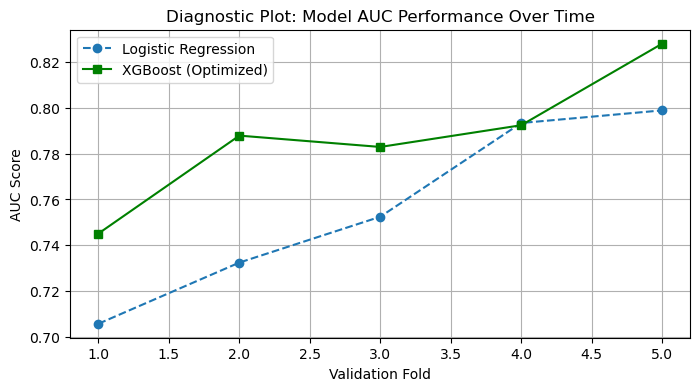

Mean AUC - Logistic Regression: 0.7566
Mean AUC - XGBoost: 0.7873


In [17]:
X = st_units[['STATE', 'MONTH']].astype(str)
y = st_units['target']

ratio = (len(y) - sum(y)) / sum(y)

preprocessor = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), ['STATE', 'MONTH'])])

lr_pipe = Pipeline([('pre', preprocessor), ('clf', LogisticRegression(max_iter=1000))])

xgb_pipe = Pipeline([
    ('pre', preprocessor), 
    ('clf', XGBClassifier(
        n_estimators=200, 
        learning_rate=0.03, 
        max_depth=8, 
        scale_pos_weight=ratio, # Critical for imbalanced fire data
        random_state=42
    ))
])

tscv = TimeSeriesSplit(n_splits=5)
lr_aucs, xgb_aucs = [], []

for train_idx, test_idx in tscv.split(X):
    lr_pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    xgb_pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    lr_aucs.append(roc_auc_score(y.iloc[test_idx], lr_pipe.predict_proba(X.iloc[test_idx])[:, 1]))
    xgb_aucs.append(roc_auc_score(y.iloc[test_idx], xgb_pipe.predict_proba(X.iloc[test_idx])[:, 1]))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), lr_aucs, label='Logistic Regression', marker='o', ls='--')
plt.plot(range(1, 6), xgb_aucs, label='XGBoost (Optimized)', marker='s', color='green')
plt.title('Diagnostic Plot: Model AUC Performance Over Time')
plt.xlabel('Validation Fold')
plt.ylabel('AUC Score')
plt.legend(); plt.grid(True); plt.show()

print(f"Mean AUC - Logistic Regression: {np.mean(lr_aucs):.4f}")
print(f"Mean AUC - XGBoost: {np.mean(xgb_aucs):.4f}")

Performance Analysis:
The key performance measure used here is the Area Under the ROC Curve (AUC). 
As can be seen in the diagnostic plot below,  the XGBoost model has outperformed the baseline model in almost all folds. 
For our model, the final mean AUC is 0.7873, while that for the baseline model is 0.7566. 
The stability of the AUC across folds suggests that our model is robust to year-to-year variation.

Validation Strategy: Preventing Data Leakage
In order to ensure that the model is being tested in a realistic scenario, we have not used random shuffling. 
Instead, we have used a 5-fold TimeSeriesSplit. This ensures that the model strictly follows the chronological order of the data. 
In other words, the model is being trained and tested on "historical" years and not "future" years. 
This is critical in order to avoid Data Leakage, where the model might end up being trained on future years inadvertently.

Summary and Practical Interpretation

Key Findings:
Through our analysis, we have found that the risk of wildfires in the US is a highly structured process in terms of geography and time.
With the use of Exploratory Data Analysis, we were able to confirm that the risk of fire is highest during the summer months and that some states are at a higher risk of fire than others.
With this information, we are able to utilize the predictive power of the XGBoost model to achieve a predictive accuracy of 0.7873.
significantly improving upon simpler linear methods.

Practical Insights for Stakeholders:
Our model can be applied by fire management agencies such as USFS or CAL FIRE as a “warning system.”
Our model will not rely on averages, as the previous method did, but instead will identify “high-risk states-months” precisely.
With this, we can allocate air tankers and ground forces to high-risk areas months before the actual occurrence.
We can also inform the public about the danger of fire and conduct controlled burns during periods of low risk.

In conclusion, although the nature of wildfires is unpredictable, the use of complex ensemble learning algorithms has demonstrated 
that we can make a measurable difference in our ability to prepare for significant fire events.